
# Boosting, Comparing GradientBoost, ADABoost, XGBoost 

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pylab as plt
import xgboost as xgb
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor



In [221]:
df = pd.read_csv("../data/housing_clean.csv")

In [222]:
df

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,day,price,renovated
0,7129300520,3,1.00,1180,5650,1.0,0,0,3,7,...,98178,47.5112,-122.257,1340,5650,2014,10,13,221900.0,0
1,6414100192,3,2.25,2570,7242,2.0,0,0,3,7,...,98125,47.7210,-122.319,1690,7639,2014,12,9,538000.0,1
2,5631500400,2,1.00,770,10000,1.0,0,0,3,6,...,98028,47.7379,-122.233,2720,8062,2015,2,25,180000.0,0
3,2487200875,4,3.00,1960,5000,1.0,0,0,5,7,...,98136,47.5208,-122.393,1360,5000,2014,12,9,604000.0,0
4,1954400510,3,2.00,1680,8080,1.0,0,0,3,8,...,98074,47.6168,-122.045,1800,7503,2015,2,18,510000.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,3,2.50,1530,1131,3.0,0,0,3,8,...,98103,47.6993,-122.346,1530,1509,2014,5,21,360000.0,0
21609,6600060120,4,2.50,2310,5813,2.0,0,0,3,8,...,98146,47.5107,-122.362,1830,7200,2015,2,23,400000.0,0
21610,1523300141,2,0.75,1020,1350,2.0,0,0,3,7,...,98144,47.5944,-122.299,1020,2007,2014,6,23,402101.0,0
21611,291310100,3,2.50,1600,2388,2.0,0,0,3,8,...,98027,47.5345,-122.069,1410,1287,2015,1,16,400000.0,0


## 1. Compare XGBoost, GradientBoost, and ADABoost 

* Just straight from the clean dataset (housing_clean.csv), without any feature engineering
* I want to compare the training and testing for each model 

In [223]:
X = df.drop(["id", "price"], axis=1)
y = df['price']

In [224]:
X

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,day,renovated
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,...,0,98178,47.5112,-122.257,1340,5650,2014,10,13,0
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,...,1991,98125,47.7210,-122.319,1690,7639,2014,12,9,1
2,2,1.00,770,10000,1.0,0,0,3,6,770,...,0,98028,47.7379,-122.233,2720,8062,2015,2,25,0
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,...,0,98136,47.5208,-122.393,1360,5000,2014,12,9,0
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,...,0,98074,47.6168,-122.045,1800,7503,2015,2,18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,3,2.50,1530,1131,3.0,0,0,3,8,1530,...,0,98103,47.6993,-122.346,1530,1509,2014,5,21,0
21609,4,2.50,2310,5813,2.0,0,0,3,8,2310,...,0,98146,47.5107,-122.362,1830,7200,2015,2,23,0
21610,2,0.75,1020,1350,2.0,0,0,3,7,1020,...,0,98144,47.5944,-122.299,1020,2007,2014,6,23,0
21611,3,2.50,1600,2388,2.0,0,0,3,8,1600,...,0,98027,47.5345,-122.069,1410,1287,2015,1,16,0


In [225]:
y

0        221900.0
1        538000.0
2        180000.0
3        604000.0
4        510000.0
           ...   
21608    360000.0
21609    400000.0
21610    402101.0
21611    400000.0
21612    325000.0
Name: price, Length: 21613, dtype: float64

In [158]:
xgb_model = XGBRegressor(random_state = 42)

xgb_model.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


[21  0 20 10 19 17  3  4 12  7  9  1 18 11 13 16  6 15 14  2  5  8]


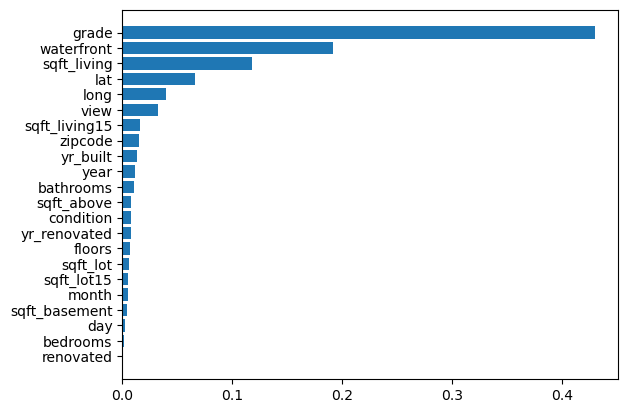

In [ ]:
sort_idx_xgb = xgb_model.feature_importances_.argsort()
print(sort_idx_xgb)

plt.barh(X.columns[sort_idx_xgb],xgb_model.feature_importances_[sort_idx_xgb])
plt.show()

In [160]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
xgb_model.fit(X_train, y_train)

# Training
y_train_pred = xgb_model.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)


print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = xgb_model.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)


print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

[335937.7  318312.75 205487.3  ... 553523.5  158018.28 347255.44]
The MSE of the training set is: 2887544150.57
The Root mean squared error of the training set is: 53735.87
The R-squared of the training set is: 0.98
The mean absolute error of the training set is: 38426.01
[3.8855738e+05 9.7344000e+05 1.1305930e+06 ... 2.9955356e+05 5.7571762e+05
 3.5973456e+05]
The MSE of the testing set is: 19949215000.39
The Root mean squared error of the testing set is: 141241.69
The R-squared of the testing set is: 0.87
The mean absolute error of the testing set is: 70240.46


| Model                 | MSE           | RMSE          | MAE       | R-squared  | Features 1 |Features 2 |Features 3   |
|-------------------    |-------------  |------------   |-------    |------------|------------|--------   |-----        |
| XGBoost - Training    | 2.89e09       | 5.34e04       | 3.84e05   |0.98        |grade       | waterfront|sqrt_living  |
| XGBoost - Testing     | 1.99e10       | 1.41e05       | 7.02e05   |0.87        |            |           |             |



In [172]:

xgb = XGBRegressor(random_state=42)

param_dist = {
    "n_estimators": [200, 300, 500, 800],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [3, 4, 6],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0]
}

# Randomized search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=40,          
    cv=3,
    scoring='r2',    
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)
print("Best parameters:", random_search.best_params_)
best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Test MSE:", mse)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best parameters: {'subsample': 0.7, 'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Test MSE: 17954909694.165165


## Now we have the best parameters, we proceed with these. 

[329919.7  307288.78 201578.56 ... 528851.94 178664.67 363037.34]
The MSE of the training set is: 3235857341.00
The Root mean squared error of the training set is: 56884.60
The R-squared of the training set is: 0.98
The mean absolute error of the training set is: 40267.90
[3.8415400e+05 8.8140231e+05 1.0977355e+06 ... 3.0235231e+05 5.8784438e+05
 3.4629400e+05]
The MSE of the testing set is: 17954909694.17
The Root mean squared error of the testing set is: 133995.93
The R-squared of the testing set is: 0.88
The mean absolute error of the testing set is: 65904.47
[ 0 19 20  4 17 18  3  7 21 10 12 11 13  9  1 16 15  6 14  2  5  8]


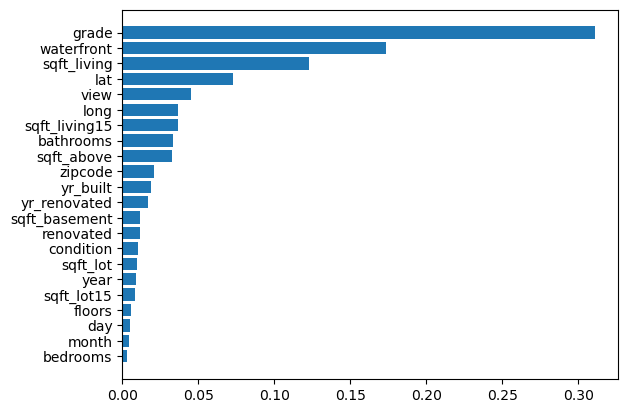

In [173]:
xgb_model = XGBRegressor(
    random_state = 42,
    n_estimators = 800,
    learning_rate = 0.03,
    max_depth = 6,
    subsample = 0.7,
    colsample_bytree = 0.7
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
xgb_model.fit(X_train, y_train)

# Training
y_train_pred = xgb_model.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)


print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = xgb_model.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)


print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

sort_idx_xgb = xgb_model.feature_importances_.argsort()
print(sort_idx_xgb)
plt.barh(X.columns[sort_idx_xgb],xgb_model.feature_importances_[sort_idx_xgb])
plt.show()

Best parameters for XGBoost {'subsample': 0.7, 'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.7}

| Model                 | MSE           | RMSE          | MAE       | R-squared  | Features 1 |Features 2 |Features 3   | 
|-------------------    |-------------  |------------   |-------    |------------|------------|--------   |-----        |
| XGBoost - Training    | 3.24e09       | 5.67e04       | 4.03e04   |0.98        |grade       | waterfront|sqrt_living  |
| XGBoost - Testing     | 1.80e10       | 1.34e05       | 6.59e04  |0.88        |            |           |             | 


## ADABoosting 

In [164]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

[816984.58135664 639065.34220705 633764.02454106 ... 775711.90509091
 633764.02454106 849348.69532909]
The MSE of the training set is: 113117266950.66
The Root mean squared error of the training set is: 336329.11
The R-squared of the training set is: 0.13
The mean absolute error of the training set is: 310497.39
[ 633764.02454106  926474.79952892 1451737.8184803  ...  775711.90509091
  775711.90509091  733985.59095951]
The MSE of the testing set is: 125193805227.91
The Root mean squared error of the testing set is: 353827.37
The R-squared of the testing set is: 0.17
The mean absolute error of the testing set is: 314456.90
[ 7  4 18 21 19 17  0 13 11  3 20 12 16  6 10  5  1  9 14 15  8  2]


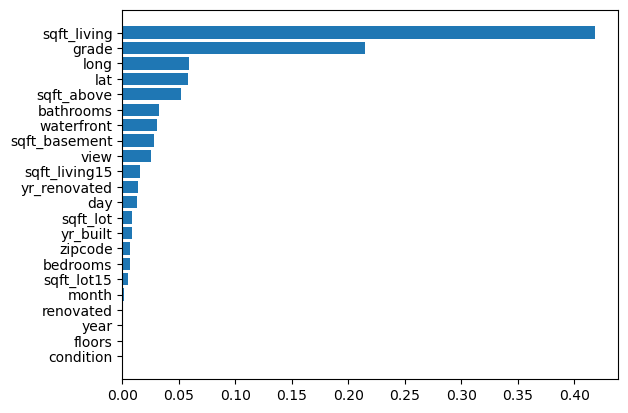

In [165]:
# abc model 1 

abc1 = AdaBoostRegressor(n_estimators=50,
                         learning_rate=1, random_state=42)

abc_model_1 = abc1.fit(X_train, y_train)

# Training 

y_train_pred = abc_model_1.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)


print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = abc_model_1.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)


print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

sort_idx_abc_1 = abc_model_1.feature_importances_.argsort()
print(sort_idx_abc_1)
plt.barh(X.columns[sort_idx_abc_1],abc_model_1.feature_importances_[sort_idx_abc_1])
plt.show()

[543403.48376068 497527.81408972 320163.35440613 ... 526285.79912602
 320163.35440613 521550.76982592]
The MSE of the training set is: 37346483045.84
The Root mean squared error of the training set is: 193252.38
The R-squared of the training set is: 0.71
The mean absolute error of the training set is: 131372.86
[ 331857.00754441  765013.37619351 1139666.1214539  ...  389505.56417625
  540535.76588459  397579.96740817]
The MSE of the testing set is: 51545239732.04
The Root mean squared error of the testing set is: 227035.77
The R-squared of the testing set is: 0.66
The mean absolute error of the testing set is: 140441.38
[ 0  7 13  9 20 21 18 17  4  3 12 10 19 16  1  6 11  5 15 14  8  2]


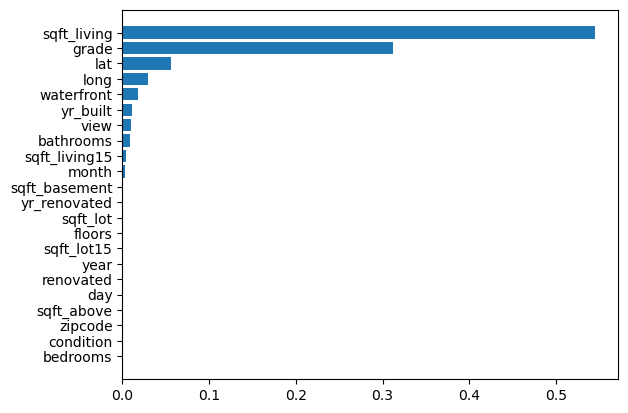

In [166]:
abc2 = AdaBoostRegressor(n_estimators=50,
                         learning_rate= 0.1, random_state=42)

abc_model_2 = abc2.fit(X_train, y_train)

# Training 

y_train_pred = abc_model_2.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)


print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = abc_model_2.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)


print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

sort_idx_abc_2 = abc_model_2.feature_importances_.argsort()
print(sort_idx_abc_2)
plt.barh(X.columns[sort_idx_abc_2],abc_model_2.feature_importances_[sort_idx_abc_2])
plt.show()

[644656.48747947 497940.18656162 387517.81750885 ... 521942.06274778
 387517.81750885 607005.19980507]
The MSE of the training set is: 40475237206.88
The Root mean squared error of the training set is: 201184.58
The R-squared of the training set is: 0.69
The mean absolute error of the training set is: 150747.61
[ 425588.56900726  701728.39618321 1341508.50397409 ...  474031.58716313
  540535.76588459  501954.4899118 ]
The MSE of the testing set is: 54696685603.25
The Root mean squared error of the testing set is: 233873.23
The R-squared of the testing set is: 0.64
The mean absolute error of the testing set is: 159456.99
[18 17  4 20  7 21 12 13  0  3 19 10 16 11  1  5  6  9 15 14  8  2]


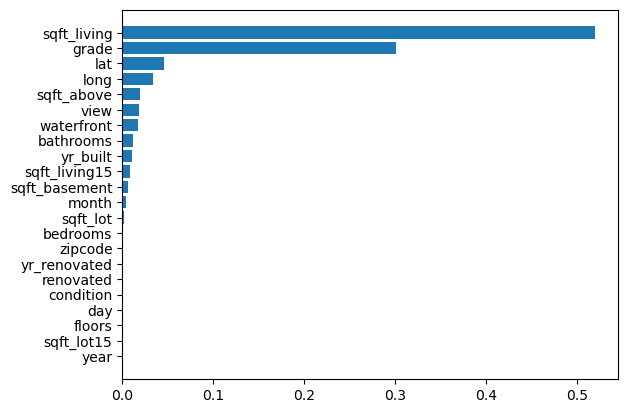

In [167]:
abc3 = AdaBoostRegressor(n_estimators=100,
                         learning_rate= 0.1, random_state=42)

abc_model_3 = abc3.fit(X_train, y_train)

# Training 

y_train_pred = abc_model_3.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)


print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = abc_model_3.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)


print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

sort_idx_abc_3 = abc_model_3.feature_importances_.argsort()
print(sort_idx_abc_3)
plt.barh(X.columns[sort_idx_abc_3],abc_model_3.feature_importances_[sort_idx_abc_3])
plt.show()

| Model                   | MSE           | RMSE          | MAE       | R-squared  | Features 1 |Features 2 |Features 3   |Notes                                    |
|-------------------      |-------------  |------------   |-------    |------------|------------|--------   |-----        |--------------------                     |
| ADABoost1 - Training    | 1.13e11       | 3.36e05       | 3.10e05   |0.13        |sqrt_living | grade     |long         |n_estimator = 50, learning_speed = 1     |
| ADABoost1 - Testing     | 1.25e11       | 3.53e05       | 3.14e05   |0.17        |            |           |             |                                         |
| ADABoost2 - Training    | 3.73e10       | 1.93e05       | 1.31e05   |0.71        |sqrt_living | grade     |lat          |n_estimator = 50, learning_speed = 0.1   |
| ADABoost2 - Testing     | 5.15e10       | 2.27e05       | 1.40e05   |0.66        |            |           |             |                                         | 
| ADABoost3 - Training    | 4.04e10       | 2.01e05       | 1.50e05   |0.69        |sqrt_living | grade     |lat          |n_estimator = 100, learning_speed = 0.1  |
| ADABoost3 - Testing     | 5.47e10       | 2.34e05       | 1.59e05   |0.64        |            |           |             |                                         |

In [169]:
base_tree = DecisionTreeRegressor()

ada = AdaBoostRegressor(
    estimator=base_tree,
    random_state=42
)

# Parameter distribution
param_dist_ada = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.5],
    "estimator__max_depth": [2, 3, 4, 6],
    "estimator__min_samples_split": [2, 5, 10]
}

random_search_ada = RandomizedSearchCV(
    estimator=ada,
    param_distributions=param_dist_ada,
    n_iter=40,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    random_state=42
)


random_search_ada.fit(X_train, y_train)
print("Best AdaBoost params:", random_search_ada.best_params_)

Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best AdaBoost params: {'n_estimators': 200, 'learning_rate': 0.1, 'estimator__min_samples_split': 2, 'estimator__max_depth': 6}


[466460.82352941 362677.1149635  262412.48120301 ... 577697.88580576
 259917.02316602 437785.0498615 ]
The MSE of the training set is: 14266854213.83
The Root mean squared error of the training set is: 119443.94
The R-squared of the training set is: 0.89
The mean absolute error of the training set is: 88271.21
[ 405910.225       886836.97774114 1149288.27860697 ...  394186.77992278
  640733.19928826  396555.07709751]
The MSE of the testing set is: 29017094404.19
The Root mean squared error of the testing set is: 170344.05
The R-squared of the testing set is: 0.81
The mean absolute error of the testing set is: 98489.11
[21 18  0  4  7 19 12 20 17  1 10  3 13  5  6  9 11 16 15 14  8  2]


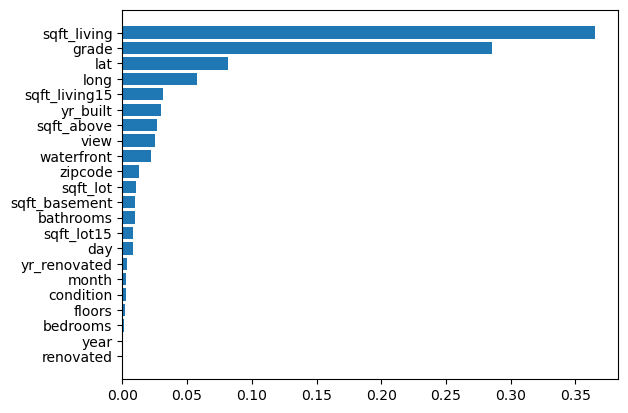

In [ ]:
base_tree = DecisionTreeRegressor(
    max_depth=6,
    min_samples_split=2,
    random_state=42
)

abc = AdaBoostRegressor(
    estimator=base_tree,
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)


abc_model = abc.fit(X_train, y_train)

# Training 

y_train_pred = abc_model.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)
print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = abc_model.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)
print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

sort_idx_abc = abc_model.feature_importances_.argsort()
print(sort_idx_abc)
plt.barh(X.columns[sort_idx_abc],abc_model.feature_importances_[sort_idx_abc])
plt.show()


Best AdaBoost params: {'n_estimators': 200, 'learning_rate': 0.1, 'estimator__min_samples_split': 2, 'estimator__max_depth': 6}

| Model                   | MSE           | RMSE          | MAE       | R-squared  | Features 1 |Features 2 |Features 3   |
|-------------------      |-------------  |------------   |-------    |------------|------------|--------   |-----        |
| ADABoost1 - Training    | 1.42e10       | 1.19e05       | 8.83e04   |0.89        |sqrt_living | grade     |lat          |
| ADABoost1 - Testing     | 2.90e10       | 1.70e05       | 9.85e04   |0.81        |            |           |             |


## Gradient Boosting 

[449681.13395101 367573.90767375 203769.61606752 ... 486704.87301574
 136892.15323622 418232.8783468 ]
The MSE of the training set is: 39478121861.53
The Root mean squared error of the training set is: 198691.02
The R-squared of the training set is: 0.70
The mean absolute error of the training set is: 95367.29
[ 374214.04661482  701085.67896098 1160995.5887829  ...  368349.19567714
  602609.45573436  389183.74567714]
The MSE of the testing set is: 47428900484.42
The Root mean squared error of the testing set is: 217781.77
The R-squared of the testing set is: 0.69
The mean absolute error of the testing set is: 102656.24
[ 4 21 20 17 19  5 12 18  3  0  1 15 10  7 11  6 13 16  9  2  8 14]


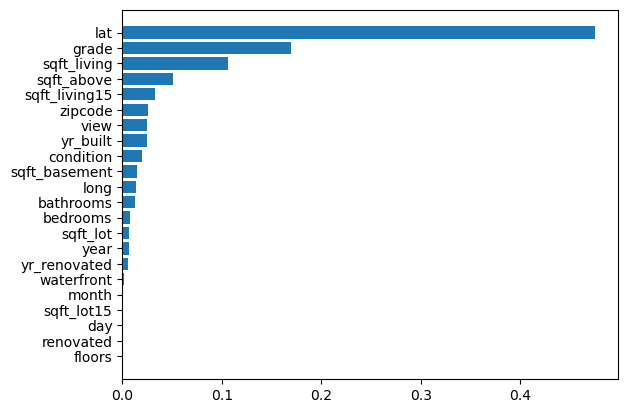

In [175]:
gbr_1 = GradientBoostingRegressor(loss='absolute_error', 
                                learning_rate=0.1,
                                n_estimators=300,
                                max_depth = 1, 
                                random_state = 42,
                                max_features = 5)

gbr_1.fit(X_train, y_train)

# Training 

y_train_pred = gbr_1.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)


print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = gbr_1.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)


print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

sort_idx_gbr_1 = gbr_1.feature_importances_.argsort()
print(sort_idx_gbr_1)
plt.barh(X.columns[sort_idx_gbr_1],gbr_1.feature_importances_[sort_idx_gbr_1])
plt.show()

[445565.04188411 365879.95606607 201854.34901956 ... 536620.46800861
 134852.51533007 407914.9133734 ]
The MSE of the training set is: 33749653132.32
The Root mean squared error of the training set is: 183710.79
The R-squared of the training set is: 0.74
The mean absolute error of the training set is: 92900.06
[ 410977.71787721  757929.00282253 1178775.89152144 ...  380846.32147941
  612374.15065786  380846.32147941]
The MSE of the testing set is: 40300035172.66
The Root mean squared error of the testing set is: 200748.69
The R-squared of the testing set is: 0.73
The mean absolute error of the testing set is: 100333.46
[ 4 19 20 17 21 18  3  5 12 15  7 10 13 11  1  0 16  6  9  2  8 14]


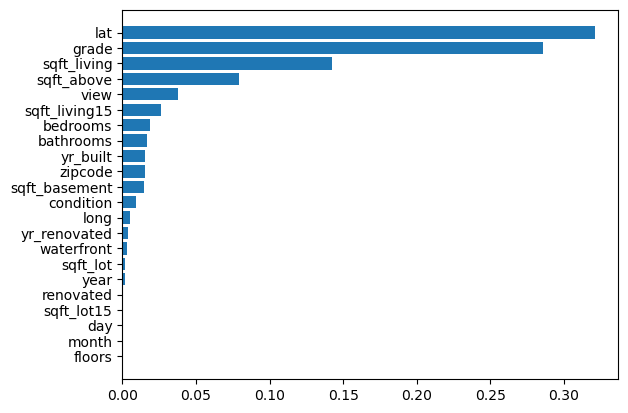

In [176]:
gbr_2 = GradientBoostingRegressor(loss='huber', 
                                learning_rate=0.1,
                                n_estimators=300,
                                max_depth = 1, 
                                random_state = 42,
                                max_features = 5)

gbr_2.fit(X_train, y_train)

# Training 

y_train_pred = gbr_2.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)


print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = gbr_2.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)


print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

sort_idx_gbr_2 = gbr_2.feature_importances_.argsort()
print(sort_idx_gbr_2)
plt.barh(X.columns[sort_idx_gbr_2],gbr_2.feature_importances_[sort_idx_gbr_2])
plt.show()

| Model                   | MSE           | RMSE          | MAE       | R-squared  | Features 1 |Features 2 |Features 3   |Notes                                    |
|-------------------      |-------------  |------------   |-------    |------------|------------|--------   |-----        |--------------------                     |
| Gradient1 - Training    | 3.94e10       | 1.97e05       | 9.54e04   |0.70        |lat         | grade     |sqrt_living  |loss = absolute error                    |
| Gradient1 - Testing     | 4.74e10       | 2.18e05       | 1.03e05   |0.69        |            |           |             |                                         |
| Gradient2 - Training    | 3.37e10       | 1.84e05       | 9.29e04   |0.74        |lat         | grade     |sqrt_living  |loss = huber                             |
| Gradient2 - Testing     | 4.03e10       | 2.01e05       | 1.00e05   |0.73        |            |           |             |                                         | 


In [ ]:
gbr = GradientBoostingRegressor(random_state=42)

param_dist = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.05, 0.1],
    "max_depth": [1, 3, 4],   
    "loss": ["squared_error", "huber"],
    "max_features": [None, "sqrt", 5],
    "subsample": [0.7, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_dist,
    n_iter=40,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    random_state=42,
    verbose=1
)


print("Best Parameters:", random_search.best_params_)


Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 500, 'max_features': 5, 'max_depth': 4, 'loss': 'squared_error', 'learning_rate': 0.1}


[337160.51261324 300909.45246384 204981.91479368 ... 530661.64935946
 174745.23922291 349330.32377261]
The MSE of the training set is: 5247435828.37
The Root mean squared error of the training set is: 72439.19
The R-squared of the training set is: 0.96
The mean absolute error of the training set is: 49502.64
[ 401323.52015846  831366.5690139  1150695.0387067  ...  303527.98774402
  607593.36677323  351971.79898174]
The MSE of the testing set is: 18711641416.70
The Root mean squared error of the testing set is: 136790.50
The R-squared of the testing set is: 0.88
The mean absolute error of the testing set is: 69271.22
[18 20  4 19 21 12  7 17  0  3 10 13  5 11 16  6  1 15  9 14  2  8]


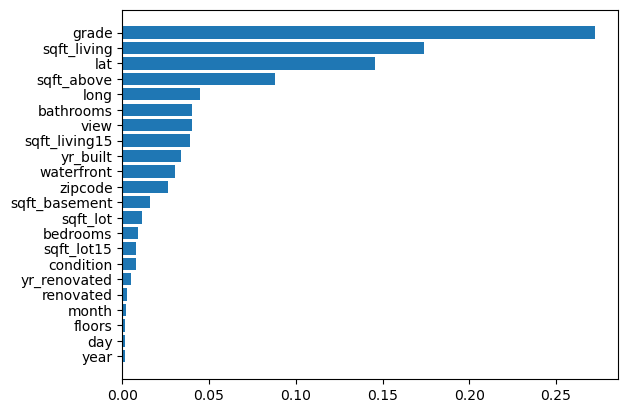

In [ ]:
gbr = GradientBoostingRegressor(
    subsample=1.0,
    n_estimators=500,
    max_features=5,
    max_depth=4,
    loss='squared_error',
    learning_rate=0.1,
    random_state=42
)

gbr.fit(X_train, y_train)

# Training 

y_train_pred = gbr.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)

print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = gbr.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)
print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

sort_idx_gbr = gbr.feature_importances_.argsort()
print(sort_idx_gbr)
plt.barh(X.columns[sort_idx_gbr],gbr.feature_importances_[sort_idx_gbr])
plt.show()

Best Parameters: {'subsample': 1.0, 'n_estimators': 500, 'max_features': 5, 'max_depth': 4, 'loss': 'squared_error', 'learning_rate': 0.1}

| Model                   | MSE           | RMSE          | MAE       | R-squared  | Features 1 |Features 2 |Features 3   |
|-------------------      |-------------  |------------   |-------    |------------|------------|--------   |-----        |
| Gradient - Training     | 5.25e9        | 7.24e04       | 4.95e04   |0.96        |grade       |sqrt_living|lat          |
| Gradient - Testing      | 1.87e10       | 1.37e05       | 6.93e04   |0.88        |            |           |             |

# Summary of XGBoost, ADABoost, Gradient Boosting compared to Linear Regression and KNN 

* Linear and KNN taken from the EDA notebook
* XGBoost, ADABoost, and Gradient Boosting with the same dataset (best parameters)

| Model                   | MAE           | R_squared     | 
|-------------------      |-------------  |------------   |
| Linear - Testing        | 1.29e5        | 0.68          | 
| KNN - Testing           | 1.01e5        | 0.77          | 
| XGBoost - Training      | 4.03e4        | 0.98          | 
| XGBoost - Testing       | 6.95e4        | 0.88          | 
| ADABoost - Training     | 8.83e4        | 0.89          | 
| ADABoost - Testing      | 9.85e4        | 0.81          | 
| Gradient - Training     | 4.95e4        | 0.96          | 
| Gradient - Testing      | 6.93e4        | 0.88          | 

# Loading the Models with the Optimized Hyperparameters

In [199]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoosting 
xgb_model = XGBRegressor(
    random_state = 42,
    n_estimators = 800,
    learning_rate = 0.03,
    max_depth = 6,
    subsample = 0.7,
    colsample_bytree = 0.7
)

# ADABoosting 
base_tree = DecisionTreeRegressor(
    max_depth=6,
    min_samples_split=2,
    random_state=42
)
abc = AdaBoostRegressor(
    estimator=base_tree,
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

# Gradient 
gbr = GradientBoostingRegressor(
    subsample=1.0,
    n_estimators=500,
    max_features=5,
    max_depth=4,
    loss='squared_error',
    learning_rate=0.1,
    random_state=42
)

In [200]:
X.nunique()

bedrooms           13
bathrooms          30
sqft_living      1038
sqft_lot         9782
floors              6
waterfront          2
view                5
condition           5
grade              12
sqft_above        946
sqft_basement     306
yr_built          116
yr_renovated       70
zipcode            70
lat              5034
long              752
sqft_living15     777
sqft_lot15       8689
year                2
month              12
day                31
renovated           2
dtype: int64

## Feature Engineering - Step 1
* lat (latitude) and long (longitude)
* I am combining them to create one feature, distance center 
* Take the median latitude and longitude, make that the center of the county, then calculate distance from that center

In [226]:
center_lat = X['lat'].median()
center_long = X['long'].median()
print(center_lat, center_long)

X['distance_center'] = np.sqrt(
    (X['lat'] - center_lat)**2 + (X['long'] - center_long)**2
)

X.nunique()

47.5718 -122.23


bedrooms              13
bathrooms             30
sqft_living         1038
sqft_lot            9782
floors                 6
waterfront             2
view                   5
condition              5
grade                 12
sqft_above           946
sqft_basement        306
yr_built             116
yr_renovated          70
zipcode               70
lat                 5034
long                 752
sqft_living15        777
sqft_lot15          8689
year                   2
month                 12
day                   31
renovated              2
distance_center    20769
dtype: int64

In [227]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [228]:
# XBG Boosting
xgb_model.fit(X_train, y_train)

# Training
y_train_pred = xgb_model.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)
print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = xgb_model.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)
print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

sort_idx_xgb = xgb_model.feature_importances_.argsort()
print(sort_idx_xgb)

[346616.12 294370.12 206148.9  ... 551144.1  161673.88 364497.  ]
The MSE of the training set is: 3089714128.14
The Root mean squared error of the training set is: 55585.20
The R-squared of the training set is: 0.98
The mean absolute error of the training set is: 39538.52
[3.7690203e+05 8.5890062e+05 1.0851412e+06 ... 3.1636106e+05 5.8261612e+05
 3.3833375e+05]
The MSE of the testing set is: 16796576300.79
The Root mean squared error of the testing set is: 129601.61
The R-squared of the testing set is: 0.89
The mean absolute error of the testing set is: 64088.96
[ 0 19 20  4  3  7 18 17 10 12 21 13 11  9 15 16  1 22  6 14  2  5  8]


In [229]:
# ADABoosting
abc_model = abc.fit(X_train, y_train)

# Training 
y_train_pred = abc_model.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)
print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = abc_model.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)
print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

sort_idx_abc = abc_model.feature_importances_.argsort()
print(sort_idx_abc)


[460598.74367089 348962.45454545 262548.96739616 ... 562621.01011303
 262548.96739616 439384.7734375 ]
The MSE of the training set is: 13398115141.52
The Root mean squared error of the training set is: 115750.23
The R-squared of the training set is: 0.90
The mean absolute error of the training set is: 86220.35
[ 432310.13529412  889520.81688889 1213850.42105263 ...  401948.85849057
  618719.80300188  404507.35613208]
The MSE of the testing set is: 24551740071.53
The Root mean squared error of the testing set is: 156689.95
The R-squared of the testing set is: 0.84
The mean absolute error of the testing set is: 96495.04
[21 18  0  4 19  7 12 20 13  1 10  3 17  9 11  5  6 16 15 22 14  8  2]


In [230]:
# Gradient Boosting 
gbr.fit(X_train, y_train)

# Training 
y_train_pred = gbr.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)

print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = gbr.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)
print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

sort_idx_gbr = gbr.feature_importances_.argsort()
print(sort_idx_gbr)


[309338.3688002  294520.46516852 221278.6101006  ... 549165.20217624
 151439.79223508 377610.57185862]
The MSE of the training set is: 5047102692.04
The Root mean squared error of the training set is: 71042.96
The R-squared of the training set is: 0.96
The mean absolute error of the training set is: 49201.36
[ 390223.99259243  896355.92803296 1160844.8193056  ...  311997.41099768
  616452.78304253  336014.67892505]
The MSE of the testing set is: 14850543531.87
The Root mean squared error of the testing set is: 121862.81
The R-squared of the testing set is: 0.90
The mean absolute error of the testing set is: 66758.89
[ 4 19 18 20 21 12  7 17  3  0 13 10 11  6  1  5 15 22 16  9 14  8  2]


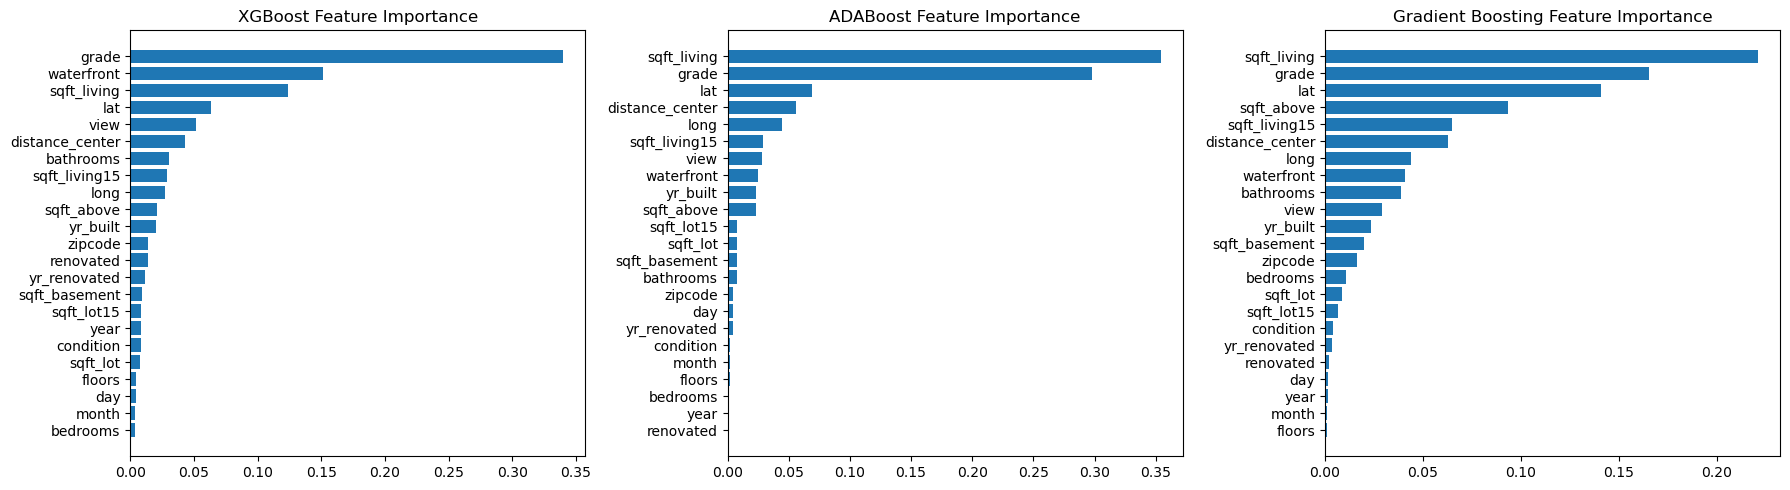

In [231]:
fig, axes = plt.subplots(1, 3, figsize = (18, 5))

# XGBoost
axes[0].barh(X.columns[sort_idx_xgb], xgb_model.feature_importances_[sort_idx_xgb])
axes[0].set_title("XGBoost Feature Importance")

#ADABoost
axes[1].barh(X.columns[sort_idx_abc], abc_model.feature_importances_[sort_idx_abc])
axes[1].set_title("ADABoost Feature Importance")

# Gradient Boosting
axes[2].barh(X.columns[sort_idx_gbr], gbr.feature_importances_[sort_idx_gbr])
axes[2].set_title("Gradient Boosting Feature Importance")

plt.tight_layout()
plt.show()

# After Step 1 of Feature Engineering 

* Adding distance center

| Model                   | MAE           | R_squared     | 
|-------------------      |-------------  |------------   |
| XGBoost - Training      | 3.93e4        | 0.98          | 
| XGBoost - Testing       | 6.41e4        | 0.89          | 
| ADABoost - Training     | 8.62e4        | 0.90          | 
| ADABoost - Testing      | 9.65e4        | 0.84          | 
| Gradient - Training     | 4.92e4        | 0.96          | 
| Gradient - Testing      | 6.68e4        | 0.90          | 

* For all the models, adding the distance center feature showed lower MAE and higher R_squared values 
* Also, for all, the R2 difference have gotten smaller, indicating a better fit

# Step 2 - Replacing Year Built with House Age
* Instead of year built, we are using the current year to subtract the year built
* Adding house_age, removing yr_built

In [232]:
X.nunique()

bedrooms              13
bathrooms             30
sqft_living         1038
sqft_lot            9782
floors                 6
waterfront             2
view                   5
condition              5
grade                 12
sqft_above           946
sqft_basement        306
yr_built             116
yr_renovated          70
zipcode               70
lat                 5034
long                 752
sqft_living15        777
sqft_lot15          8689
year                   2
month                 12
day                   31
renovated              2
distance_center    20769
dtype: int64

In [ ]:
X['house_age'] = 2026 - X['yr_built'] 

X = X.drop(["yr_built"], axis=1)

X.nunique()

bedrooms              13
bathrooms             30
sqft_living         1038
sqft_lot            9782
floors                 6
waterfront             2
view                   5
condition              5
grade                 12
sqft_above           946
sqft_basement        306
yr_renovated          70
zipcode               70
lat                 5034
long                 752
sqft_living15        777
sqft_lot15          8689
year                   2
month                 12
day                   31
renovated              2
distance_center    20769
house_age            116
dtype: int64

In [240]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [241]:
# XBG Boosting
xgb_model.fit(X_train, y_train)

# Training
y_train_pred = xgb_model.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)
print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = xgb_model.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)
print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

sort_idx_xgb = xgb_model.feature_importances_.argsort()
print(sort_idx_xgb)

[340663.53 296713.12 198489.45 ... 550998.4  169196.39 376222.9 ]
The MSE of the training set is: 3081910535.63
The Root mean squared error of the training set is: 55514.96
The R-squared of the training set is: 0.98
The mean absolute error of the training set is: 39582.92
[3.8058344e+05 8.6531138e+05 1.0977966e+06 ... 3.1270016e+05 5.7690488e+05
 3.3083872e+05]
The MSE of the testing set is: 17420462526.56
The Root mean squared error of the testing set is: 131986.60
The R-squared of the testing set is: 0.88
The mean absolute error of the testing set is: 65055.07
[ 0 18 19  4 20  7  3 17 16 10 11 12  9 22 14  1 15 21  6 13  2  5  8]


In [242]:
# ADABoosting
abc_model = abc.fit(X_train, y_train)

# Training 
y_train_pred = abc_model.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)
print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = abc_model.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)
print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

sort_idx_abc = abc_model.feature_importances_.argsort()
print(sort_idx_abc)

[452693.11660777 354126.74782609 263845.97735849 ... 556517.87253142
 263543.24489796 443153.03157895]
The MSE of the training set is: 13324915575.31
The Root mean squared error of the training set is: 115433.60
The R-squared of the training set is: 0.90
The mean absolute error of the training set is: 86148.22
[ 429240.97354497  892451.55677155 1182003.06875    ...  401356.62252346
  628606.7968254   406484.18026969]
The MSE of the testing set is: 23357995148.52
The Root mean squared error of the testing set is: 152833.23
The R-squared of the testing set is: 0.85
The mean absolute error of the testing set is: 96370.88
[20 17  0  7  4 18 11 19 12 10  1  3 16  9 22  5  6 15 14 21 13  8  2]


In [243]:
# Gradient Boosting 
gbr.fit(X_train, y_train)

# Training 
y_train_pred = gbr.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)

print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = gbr.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)
print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

sort_idx_gbr = gbr.feature_importances_.argsort()
print(sort_idx_gbr)

[329863.28992405 298997.03262419 206365.24441279 ... 543185.36465464
 157080.64839056 387034.56594477]
The MSE of the training set is: 4996611652.19
The Root mean squared error of the training set is: 70686.71
The R-squared of the training set is: 0.96
The mean absolute error of the training set is: 48916.17
[ 388019.26552944  880537.85154911 1151337.58684827 ...  315414.04655222
  621928.6589448   335192.03115313]
The MSE of the testing set is: 16106044412.92
The Root mean squared error of the testing set is: 126909.59
The R-squared of the testing set is: 0.89
The mean absolute error of the testing set is: 66917.64
[ 4 17 19 20 18  0 11  7  3 16 22 12 10  1  5  6 14 15 21  9 13  8  2]


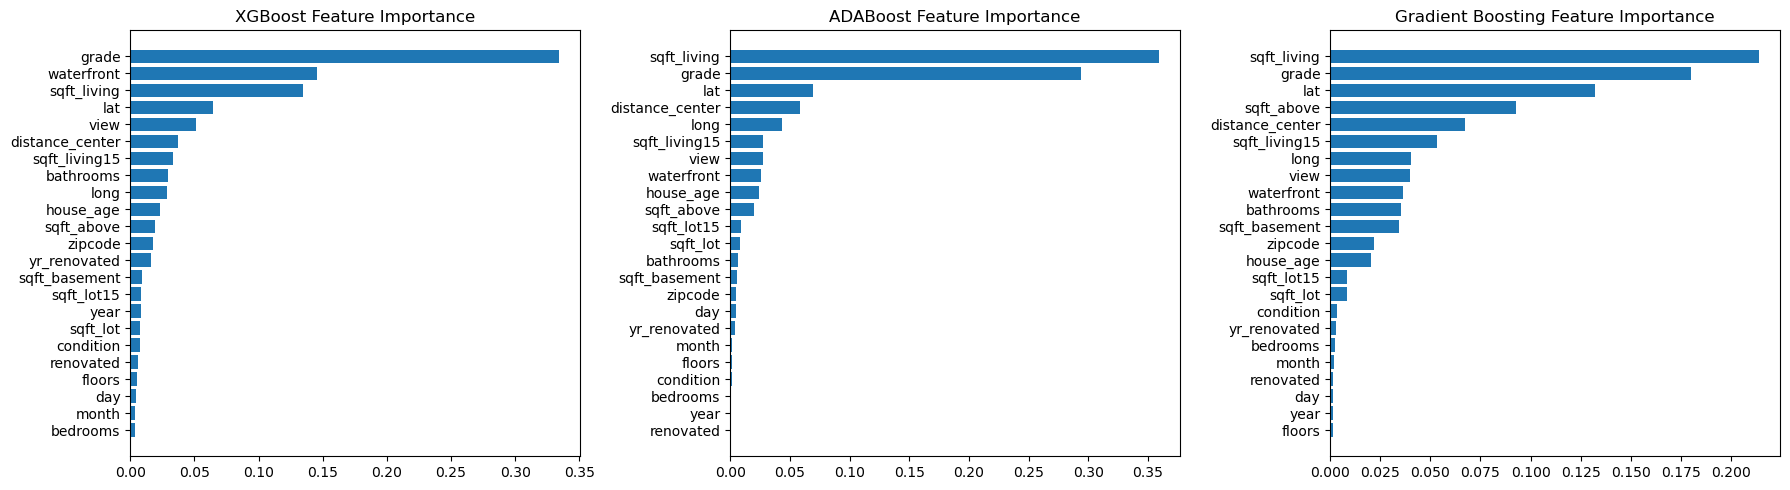

In [244]:
fig, axes = plt.subplots(1, 3, figsize = (18, 5))

# XGBoost
axes[0].barh(X.columns[sort_idx_xgb], xgb_model.feature_importances_[sort_idx_xgb])
axes[0].set_title("XGBoost Feature Importance")

#ADABoost
axes[1].barh(X.columns[sort_idx_abc], abc_model.feature_importances_[sort_idx_abc])
axes[1].set_title("ADABoost Feature Importance")

# Gradient Boosting
axes[2].barh(X.columns[sort_idx_gbr], gbr.feature_importances_[sort_idx_gbr])
axes[2].set_title("Gradient Boosting Feature Importance")

plt.tight_layout()
plt.show()

# After Step 2 of Feature Engineering 

* Replacing the year built with house age 

| Model                   | MAE           | R_squared     | 
|-------------------      |-------------  |------------   |
| XGBoost - Training      | 3.96e4        | 0.98          | 
| XGBoost - Testing       | 6.50e4        | 0.88          | 
| ADABoost - Training     | 8.61e4        | 0.90          | 
| ADABoost - Testing      | 9.64e4        | 0.85          | 
| Gradient - Training     | 4.89e4        | 0.96          | 
| Gradient - Testing      | 6.69e4        | 0.89          | 

* R2 values remained the same and the differences between training and testing set remained the same 
* MAE remained unchanged

# Feature Engineering Step 3 

### Creating a feature, grade*sqft_living, here combining the two columns, where we get an idea about size and quality. 
* grade * sqft_living
* Big and higher grade = luxury, small and higher grade = premium but compact

### Creating a feature, living ratio
* Considering the portion of living space 
* Living space (sqft_living) divided by the whole lot space (sqft_lot)

### Creating a feature, total sqft
* space above (sqft_above) plus space in the basement (sqft_basement)
* Buyers want to know about the whole space information, to see how much money they're putting in and how much space in total they are getting back 


In [245]:
X.nunique()

bedrooms              13
bathrooms             30
sqft_living         1038
sqft_lot            9782
floors                 6
waterfront             2
view                   5
condition              5
grade                 12
sqft_above           946
sqft_basement        306
yr_renovated          70
zipcode               70
lat                 5034
long                 752
sqft_living15        777
sqft_lot15          8689
year                   2
month                 12
day                   31
renovated              2
distance_center    20769
house_age            116
dtype: int64

In [246]:
X['grade * sqft_living'] = X['grade'] * X['sqft_living']
X['living_ratio'] = X['sqft_living'] / X['sqft_lot']
X['total_sqft'] = X['sqft_above'] + X['sqft_basement']
#X = X.drop(["grade", "sqft_living", "sqft_lot", "sqft_above", "sqft_basement"], axis=1)
X.nunique()

bedrooms                  13
bathrooms                 30
sqft_living             1038
sqft_lot                9782
floors                     6
waterfront                 2
view                       5
condition                  5
grade                     12
sqft_above               946
sqft_basement            306
yr_renovated              70
zipcode                   70
lat                     5034
long                     752
sqft_living15            777
sqft_lot15              8689
year                       2
month                     12
day                       31
renovated                  2
distance_center        20769
house_age                116
grade * sqft_living     2122
living_ratio           19154
total_sqft              1038
dtype: int64

In [247]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [248]:
# XBG Boosting
xgb_model.fit(X_train, y_train)

# Training
y_train_pred = xgb_model.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)
print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = xgb_model.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)
print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

sort_idx_xgb = xgb_model.feature_importances_.argsort()
print(sort_idx_xgb)

[347725.38 299910.7  210024.11 ... 537735.75 188025.45 371456.62]
The MSE of the training set is: 3011560593.61
The Root mean squared error of the training set is: 54877.69
The R-squared of the training set is: 0.98
The mean absolute error of the training set is: 39234.36
[3.8059738e+05 8.9995644e+05 1.1212739e+06 ... 3.1138456e+05 6.0677038e+05
 3.4048641e+05]
The MSE of the testing set is: 16758574609.15
The Root mean squared error of the testing set is: 129454.91
The R-squared of the testing set is: 0.89
The mean absolute error of the testing set is: 64100.15
[18  0 19  4 24  7 10  3 17 16  9 11 12 15 22  1 20 14  6 21  2 13  8  5
 25 23]


In [249]:
# ADABoosting
abc_model = abc.fit(X_train, y_train)

# Training 
y_train_pred = abc_model.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)
print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = abc_model.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)
print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

sort_idx_abc = abc_model.feature_importances_.argsort()
print(sort_idx_abc)

[362408.72859745 342596.39166667 256909.42056075 ... 591326.23830318
 257675.70435548 431713.92409241]
The MSE of the training set is: 12902966142.92
The Root mean squared error of the training set is: 113591.22
The R-squared of the training set is: 0.90
The mean absolute error of the training set is: 83340.11
[ 383005.84129693  960638.53133515 1175790.59079903 ...  394783.33093525
  644130.7592955   396149.02312139]
The MSE of the testing set is: 23332166266.05
The Root mean squared error of the testing set is: 152748.70
The R-squared of the testing set is: 0.85
The mean absolute error of the testing set is: 93402.83
[20 17  0  7  4 18 24 12  1 10 11  3 19 16  2 25  9 22 15  6  5 14 21 13
  8 23]


In [250]:
# Gradient Boosting 
gbr.fit(X_train, y_train)

# Training 
y_train_pred = gbr.predict(X_train)
print(y_train_pred)
MSE_training = mean_squared_error(y_train, y_train_pred)
R2_training = r2_score(y_train, y_train_pred)
MAE_training = mean_absolute_error(y_train, y_train_pred)

print(f"The MSE of the training set is: {MSE_training:.2f}")
print(f"The Root mean squared error of the training set is: {MSE_training**0.5:.2f}")
print(f"The R-squared of the training set is: {R2_training:.2f}")
print(f"The mean absolute error of the training set is: {MAE_training:.2f}")

# Testing 
y_test_pred = gbr.predict(X_test)
print(y_test_pred)
MSE_testing = mean_squared_error(y_test, y_test_pred)
R2_testing = r2_score(y_test, y_test_pred)
MAE_testing = mean_absolute_error(y_test, y_test_pred)
print(f"The MSE of the testing set is: {MSE_testing:.2f}")
print(f"The Root mean squared error of the testing set is: {MSE_testing**0.5:.2f}")
print(f"The R-squared of the testing set is: {R2_testing:.2f}")
print(f"The mean absolute error of the testing set is: {MAE_testing:.2f}")

sort_idx_gbr = gbr.feature_importances_.argsort()
print(sort_idx_gbr)

[318569.70514397 291778.06058294 205826.37035621 ... 531862.83275989
 191617.10475434 394854.96574387]
The MSE of the training set is: 4886953592.23
The Root mean squared error of the training set is: 69906.75
The R-squared of the training set is: 0.96
The mean absolute error of the training set is: 48454.54
[ 384944.26361248  858491.85553305 1117455.26645497 ...  294960.18220266
  618663.74483107  347821.26919386]
The MSE of the testing set is: 17554077765.51
The Root mean squared error of the testing set is: 132491.80
The R-squared of the testing set is: 0.88
The mean absolute error of the testing set is: 67810.67
[20  4  0 18 17 11 19  7 24 16  3 10 12  1  5  6 22 14  2 15 25 21 13  8
  9 23]


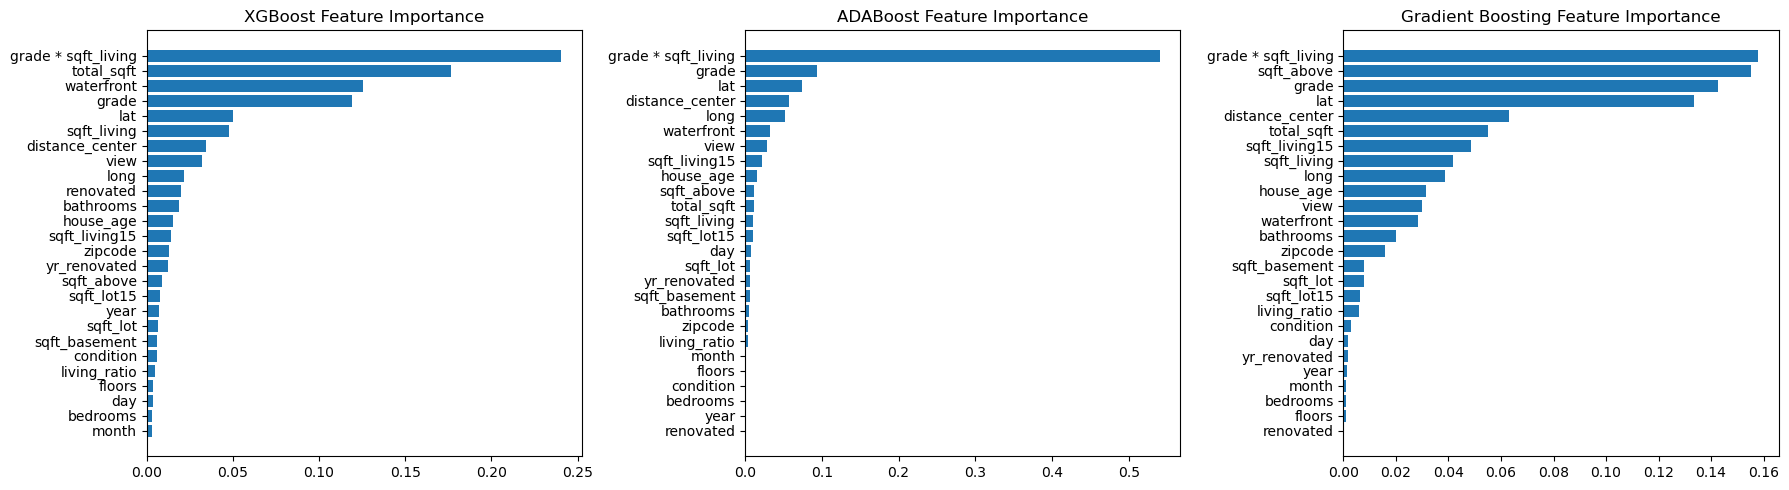

In [251]:
fig, axes = plt.subplots(1, 3, figsize = (18, 5))

# XGBoost
axes[0].barh(X.columns[sort_idx_xgb], xgb_model.feature_importances_[sort_idx_xgb])
axes[0].set_title("XGBoost Feature Importance")

#ADABoost
axes[1].barh(X.columns[sort_idx_abc], abc_model.feature_importances_[sort_idx_abc])
axes[1].set_title("ADABoost Feature Importance")

# Gradient Boosting
axes[2].barh(X.columns[sort_idx_gbr], gbr.feature_importances_[sort_idx_gbr])
axes[2].set_title("Gradient Boosting Feature Importance")

plt.tight_layout()
plt.show()

- After feature engineering, we observe that the combined feature grade*sqft_living consistently rank as the most important across all three boosting models. 
- This indicates that the interaction between house quality and living area is a strong predictor of price.
- Additionally, engineered features such as distance_center and house_age also contribute meaningfully, appearing among the top features. 
- While the ranking order varies slightly between models, the consistency of key features across model suggests successful feature engineering capturing important patterns of data. 

# After Step 3 of Feature Engineering

* Three new features

| Model                   | MAE           | R_squared     | 
|-------------------      |-------------  |------------   |
| XGBoost - Training      | 3.92e4        | 0.98          | 
| XGBoost - Testing       | 6.41e4        | 0.89          | 
| ADABoost - Training     | 8.33e4        | 0.90          | 
| ADABoost - Testing      | 9.34e4        | 0.85          | 
| Gradient - Training     | 4.86e4        | 0.96          | 
| Gradient - Testing      | 6.78e4        | 0.88          | 

* MAE improved for all three models
* R2 values and differences between training and testing remained the same 

# Summary 

### Before Feature Engineering 


| Model                   | MAE           | R_squared     | 
|-------------------      |-------------  |------------   |
| Linear - Testing        | 1.29e5        | 0.68          | 
| KNN - Testing           | 1.01e5        | 0.77          | 
| XGBoost - Training      | 4.03e4        | 0.98          | 
| XGBoost - Testing       | 6.95e4        | 0.88          | 
| ADABoost - Training     | 8.83e4        | 0.89          | 
| ADABoost - Testing      | 9.85e4        | 0.81          | 
| Gradient - Training     | 4.95e4        | 0.96          | 
| Gradient - Testing      | 6.93e4        | 0.88          | 



### After Feature Engineering 

| Model                   | MAE           | R_squared     | 
|-------------------      |-------------  |------------   |
| XGBoost - Training      | 3.92e4        | 0.98          | 
| XGBoost - Testing       | 6.41e4        | 0.89          | 
| ADABoost - Training     | 8.33e4        | 0.90          | 
| ADABoost - Testing      | 9.34e4        | 0.85          | 
| Gradient - Training     | 4.86e4        | 0.96          | 
| Gradient - Testing      | 6.78e4        | 0.88          | 

- Compared to baseline models (Linear Regression and KNN), all three boosting models achieved significantly better performance, with lower mean absolute error (MAE) and higher R2 scores.
- After feature engineering, model performance improved slightly, particularly for XGBoost, indicating that the newly engineered features added useful information without removing important existing features. 
- While all models show slight overfitting, XBGoost demostrates the best balance between bias and variance, achieving the highest predictive performance on the test set. 
- Among the three demonstrated here, XGBoost is selected as the final model for house price prediction. 
